In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error





In [5]:


# Hours studied
X = np.array([1,2,3,4,5,6,7,8]).reshape(-1, 1)

# True function: y = 5x + 0.5x^2 (plus small noise)
y = 5*X.flatten() + 0.5*(X.flatten()**2)

# Optionally add tiny noise to make it realistic
rng = np.random.default_rng(42)
noise = rng.normal(0, 1, size=len(y))
y = y + noise

df = pd.DataFrame({"hours": X.flatten(), "marks": y})
print(df)


   hours      marks
0      1   5.804717
1      2  10.960016
2      3  20.250451
3      4  28.940565
4      5  35.548965
5      6  46.697820
6      7  59.627840
7      8  71.683757


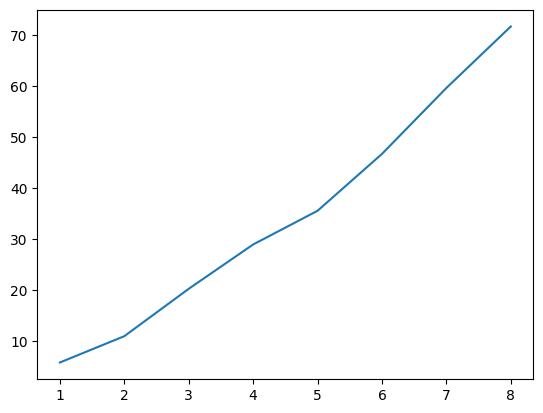

In [3]:
plt.plot(df['hours'], df['marks'])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df[['hours']], df['marks'], test_size= 0.2, random_state= 42)

In [11]:
X_train

,hours
0,1
7,8
2,3
4,5
3,4
6,7


## Underfitting

Model is too simple and cannot learn the pattern.
It does not understand the relationship between input and output.

Super easy example:

You want to predict marks from hours studied.

Real pattern:
More hours → more marks

But an underfitting model says:
“I don’t care about hours… everyone gets 50 marks.”

So:
1 hour studied  → predicted 50
8 hours studied → predicted 50

Why is this wrong?
Because the model is too simple and ignores important information.

One-line definition:
Underfitting = Model is too dumb → learns nothing → performs badly on both train and test data.


In [13]:

# UNDERFITTING MODEL: predict mean of training marks
y_train_mean = y_train.mean()

y_pred_train_under = np.full(len(y_train), y_train_mean)
y_pred_test_under  = np.full(len(y_test), y_train_mean)

mse_train_under = mean_squared_error(y_train, y_pred_train_under)
mse_test_under  = mean_squared_error(y_test, y_pred_test_under)

print("Underfitting Model:")
print("Train MSE =", mse_train_under)
print("Test  MSE =", mse_test_under)


Underfitting Model:
Train MSE = 505.95530153781675
Test  MSE = 385.6734141583807


In [14]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_train_lin = lin_model.predict(X_train)
y_pred_test_lin  = lin_model.predict(X_test)

mse_train_lin = mean_squared_error(y_train, y_pred_train_lin)
mse_test_lin  = mean_squared_error(y_test, y_pred_test_lin)

print("\nLinear Regression Model:")
print("Train MSE =", mse_train_lin)
print("Test  MSE =", mse_test_lin)



Linear Regression Model:
Train MSE = 7.942553390717081
Test  MSE = 4.506333414717597


In [17]:
from sklearn.linear_model import LinearRegression

ln = LinearRegression()
ln_model = ln.fit(X_train, y_train)
y_pred_train = ln_model.predict(X_train)
y_pred_test = ln_model.predict(X_test)